In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv("data/BIKE DETAILS.csv")
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [3]:
df.shape

(1061, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.1+ KB


In [5]:
df.dtypes

name                  object
selling_price          int64
year                   int64
seller_type           object
owner                 object
km_driven              int64
ex_showroom_price    float64
dtype: object

In [6]:
df.describe()

,selling_price,year,km_driven,ex_showroom_price
count,1061.000000,1061.000000,1061.000000,6.260000e+02
mean,59638.151744,2013.867107,34359.833176,8.795871e+04
std,56304.291973,4.301191,51623.152702,7.749659e+04
min,5000.000000,1988.000000,350.000000,3.049000e+04
25%,28000.000000,2011.000000,13500.000000,5.485200e+04
50%,45000.000000,2015.000000,25000.000000,7.275250e+04
75%,70000.000000,2017.000000,43000.000000,8.703150e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


In [7]:
df.duplicated().any()

True

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    433
dtype: int64

In [10]:
df.dropna(subset=["ex_showroom_price"], inplace=True)

In [11]:
df["Age"]=2025-df["year"]
df.drop(columns=["year"], inplace=True)

In [12]:
cat_cols=df.select_dtypes(include="object").columns

for col in cat_cols:
    if df[col].nunique()<10:
        print(col,"-",df[col].nunique(),"-",df[col].unique())
    else:
        print(col,"-",df[col].nunique())

name - 183
seller_type - 2 - ['Individual' 'Dealer']
owner - 4 - ['1st owner' '2nd owner' '3rd owner' '4th owner']


In [13]:
num_cols=df.select_dtypes(include="number").columns

for col in num_cols:
    if df[col].nunique()<10:
        print(col,"-",df[col].nunique(),"-",df[col].unique())
    else:
        print(col,"-",df[col].nunique())

selling_price - 99
km_driven - 219
ex_showroom_price - 230
Age - 18


Individual    619
Dealer          3
Name: seller_type, dtype: int64


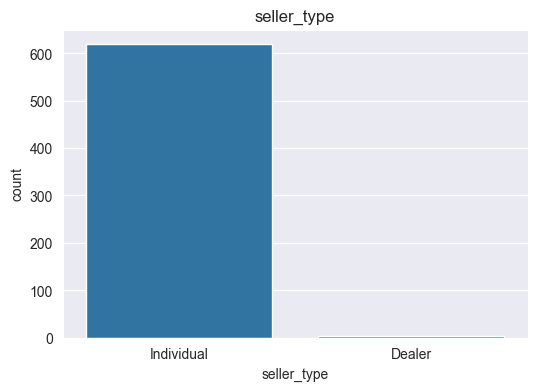

1st owner    552
2nd owner     66
3rd owner      3
4th owner      1
Name: owner, dtype: int64


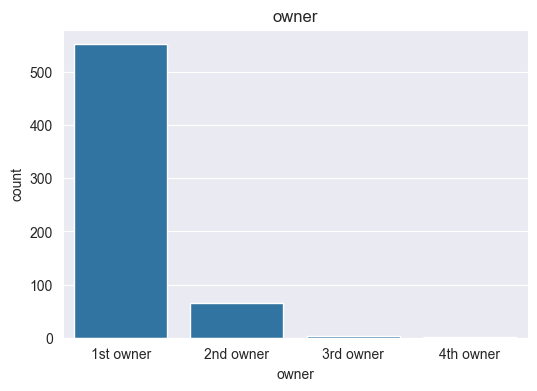

In [14]:
for col in cat_cols:
    if df[col].nunique()<10:
        print(df[col].value_counts())
        plt.figure(figsize=[6,4])
        sns.countplot(x=df[col])
        plt.title(col)
        plt.show()

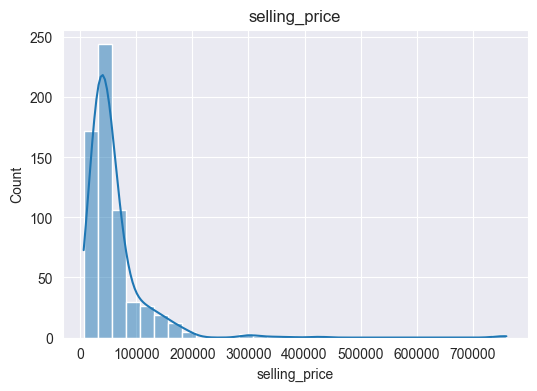

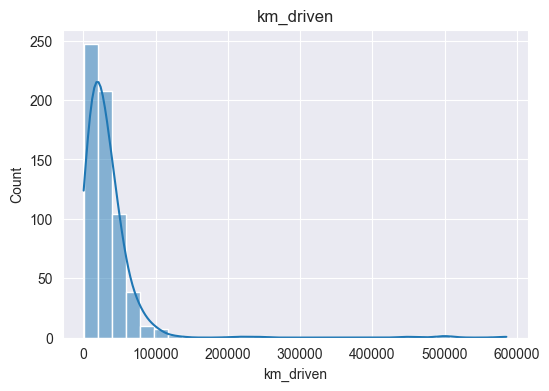

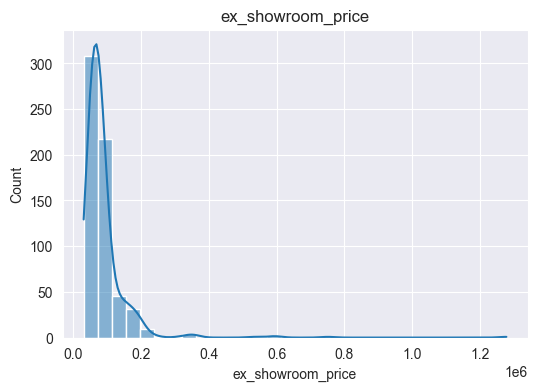

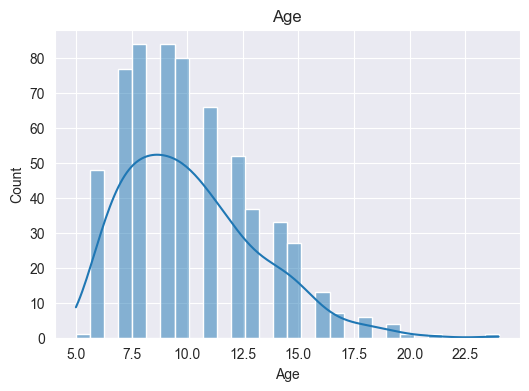

In [15]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.show()

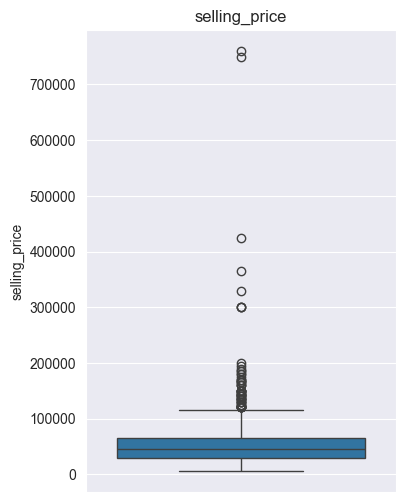

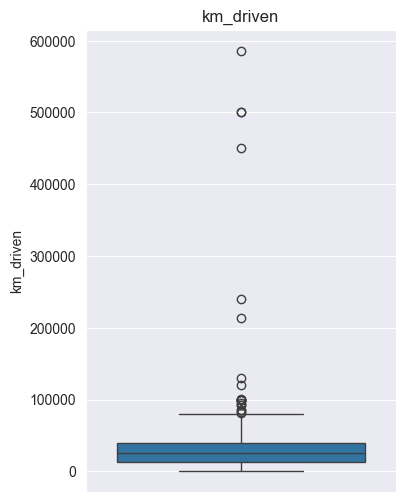

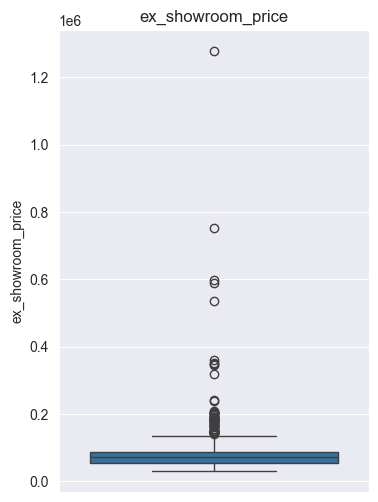

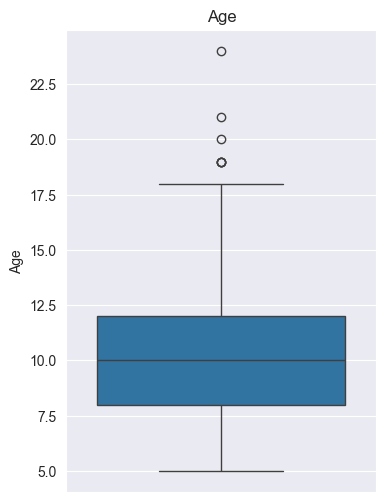

In [16]:
for col in num_cols:
    plt.figure(figsize=(4,6))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

In [17]:
for col in num_cols:
    df[col + "_log"] = np.log(df[col])

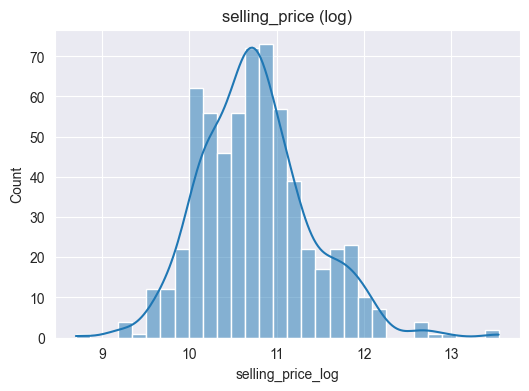

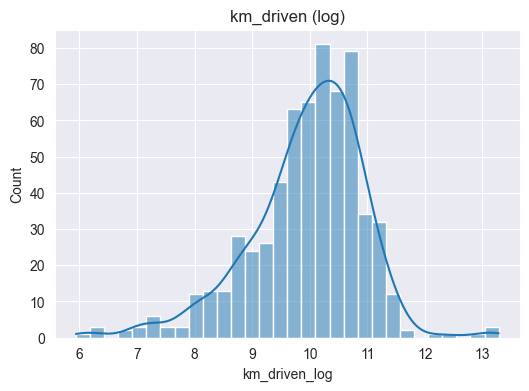

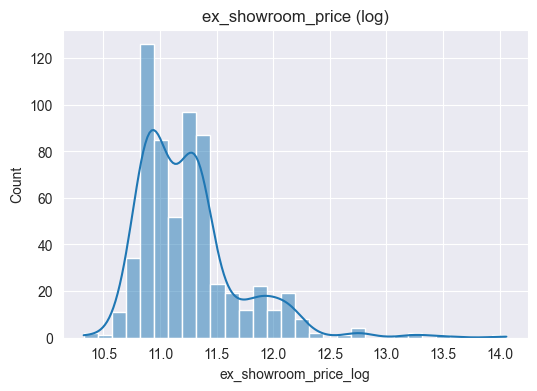

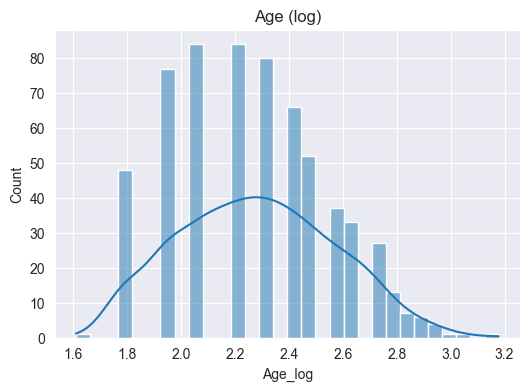

In [18]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col + "_log"], bins=30, kde=True)
    plt.title(col + " (log)")
    plt.show()

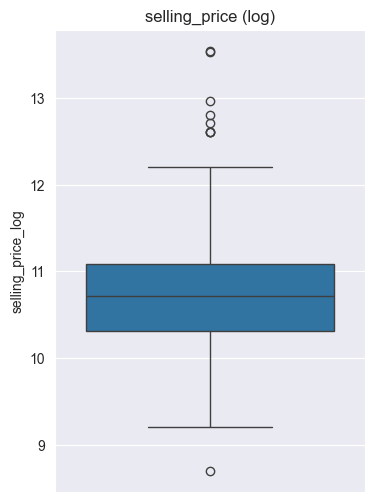

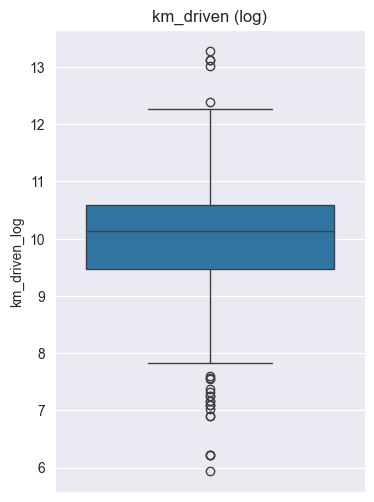

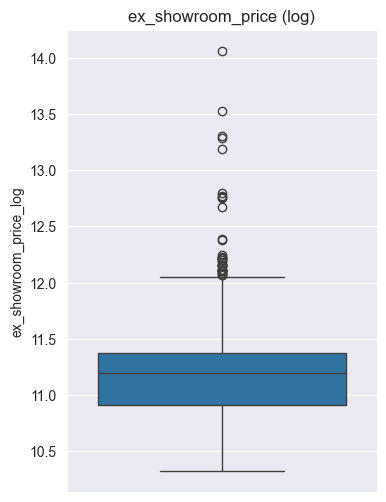

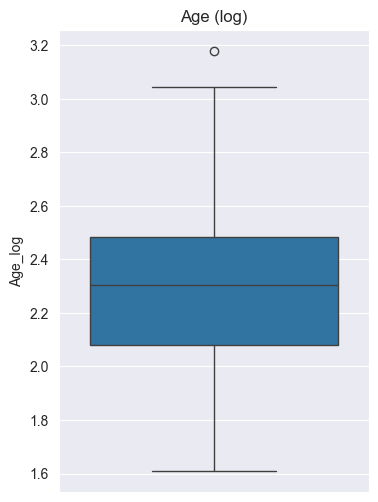

In [19]:
for col in num_cols:
    plt.figure(figsize=(4,6))
    sns.boxplot(y=df[col + "_log"])
    plt.title(col + " (log)")
    plt.show()

In [20]:
from scipy.stats import f_oneway

for col in cat_cols:
    if df[col].nunique() < 10:
        groups = [group['selling_price'].values for name, group in df.groupby(col)]
        print(col, f_oneway(*groups))

# Biến phân loại có ảnh hưởng tới Selling Price: seller_type, owner

seller_type F_onewayResult(statistic=0.011847651757735705, pvalue=0.9133591264518888)
owner F_onewayResult(statistic=7.307203605363091, pvalue=8.056547717196725e-05)


In [21]:
corr = df[num_cols].corr()
corr['selling_price'].sort_values(ascending=False)

# Biến số có ảnh hưởng tới Revenue: ex_showroom_price, km_driven, Age

selling_price        1.000000
ex_showroom_price    0.918659
km_driven           -0.192232
Age                 -0.348976
Name: selling_price, dtype: float64

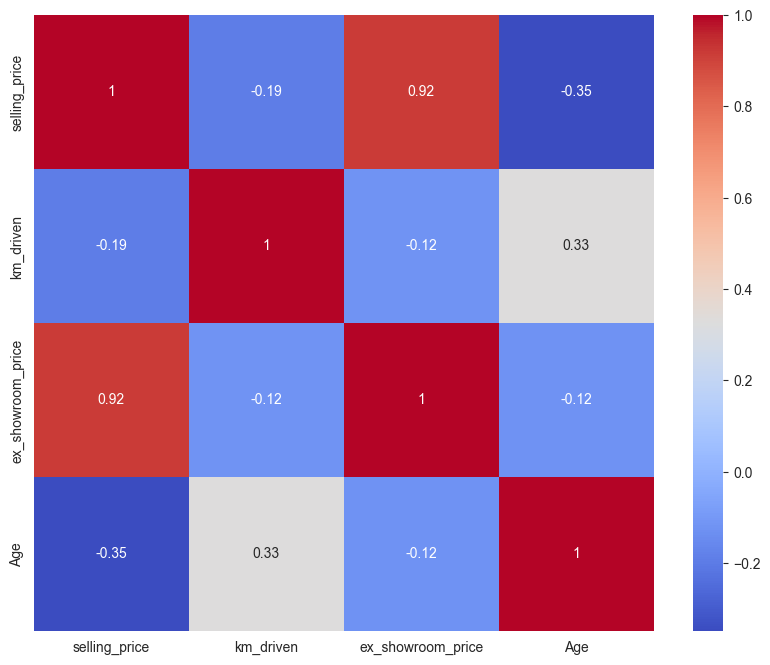

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

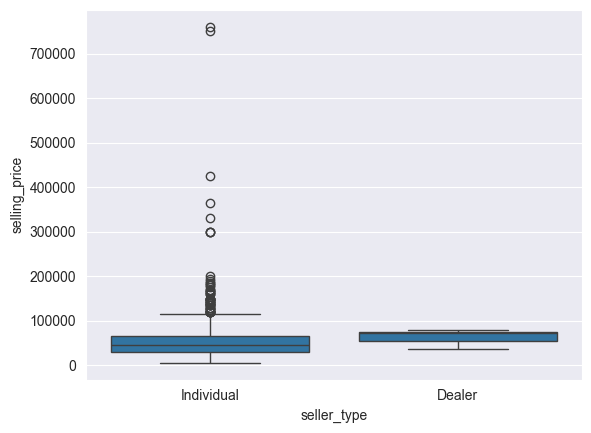

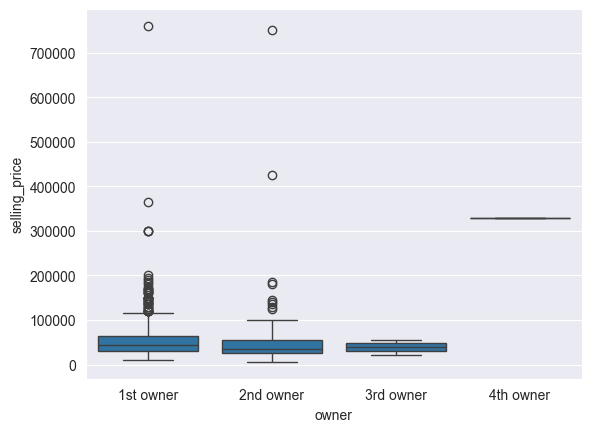

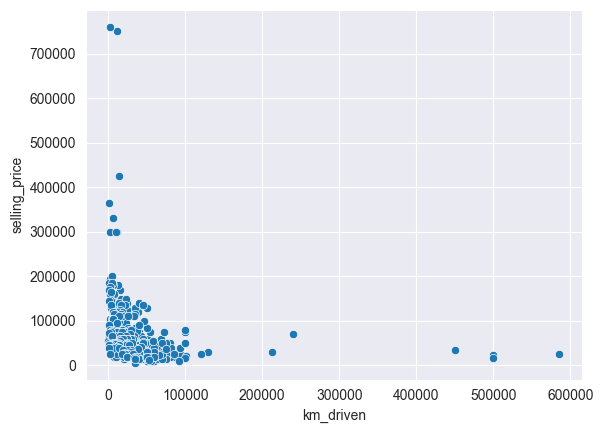

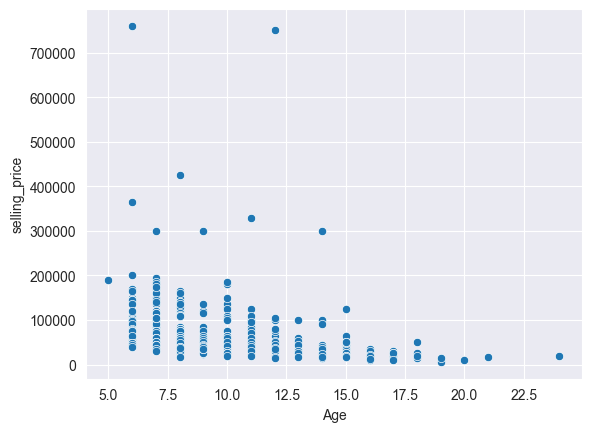

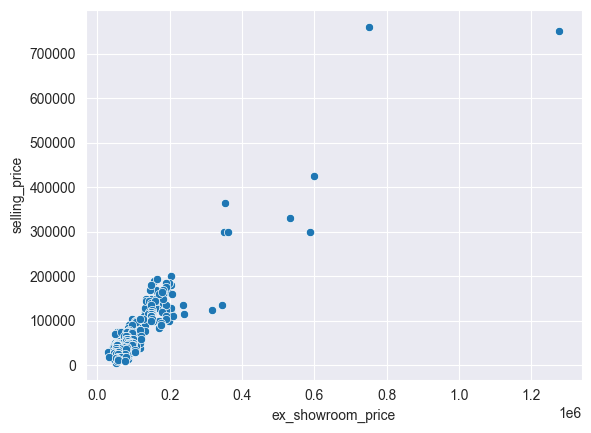

In [23]:
sns.boxplot(x = "seller_type",y="selling_price", data= df)
plt.show()

sns.boxplot(x = "owner",y="selling_price", data= df)
plt.show()

sns.scatterplot(x = "km_driven",y="selling_price", data= df)
plt.show()

sns.scatterplot(x = "Age",y="selling_price", data= df)
plt.show()

sns.scatterplot(x = "ex_showroom_price",y="selling_price", data= df)
plt.show()

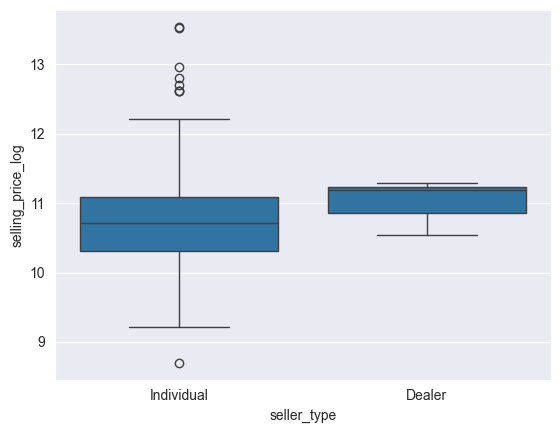

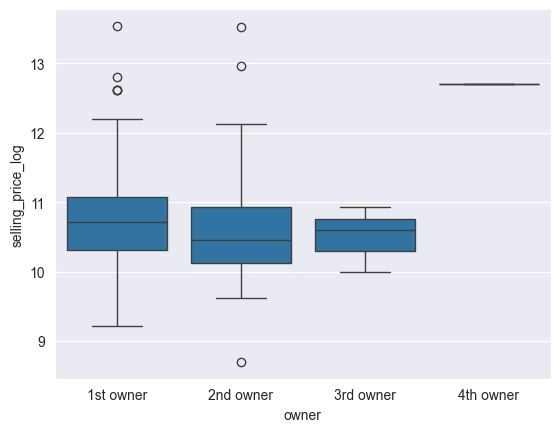

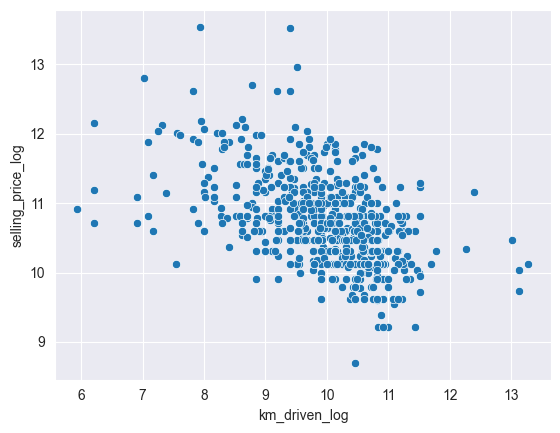

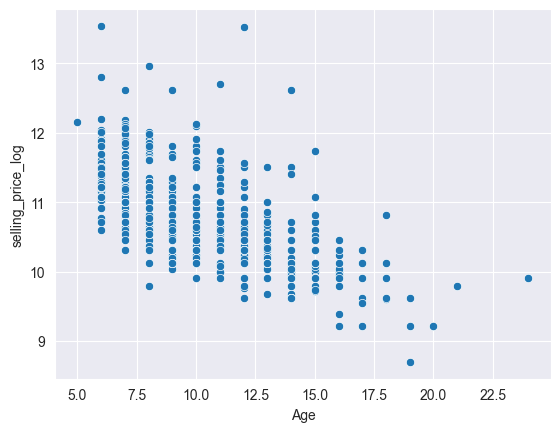

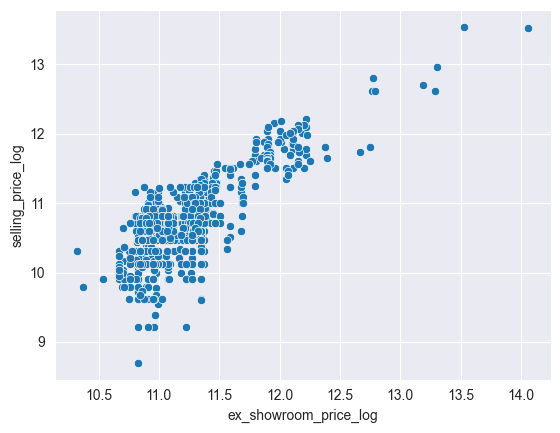

In [24]:
sns.boxplot(x = "seller_type",y="selling_price_log", data= df)
plt.show()

sns.boxplot(x = "owner",y="selling_price_log", data= df)
plt.show()

sns.scatterplot(x = "km_driven_log",y="selling_price_log", data= df)
plt.show()

sns.scatterplot(x = "Age",y="selling_price_log", data= df)
plt.show()

sns.scatterplot(x = "ex_showroom_price_log",y="selling_price_log", data= df)
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [26]:
# Seller_type: Individual=1, Dealler=0
# Owner: 1st owner=0, 2nd owner=1, 3rd owner=2, 4th owner=3
df['seller_type'] = le.fit_transform(df['seller_type'])
df['owner'] = le.fit_transform(df['owner'])


In [27]:
X=df[["km_driven_log","Age","owner","seller_type","ex_showroom_price_log"]]
y = df["selling_price_log"]

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
print('The full R-square is:', model.score(X,y))
print('The train R-square is:', model.score(X_train,y_train))
print('The test R-square is:', model.score(X_test,y_test))

The full R-square is: -1.4859234798490917
The train R-square is: 0.8534559283661353
The test R-square is: 0.904760297523922


In [33]:
print("Coefficient : ", model.coef_)
print("Intercept : ", model.intercept_)

Coefficient :  [-0.06248674 -0.33920195 -0.05575066  0.05139046  0.41869051]
Intercept :  10.706159237210645


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [35]:
yhat = model.predict(X_test)

In [36]:
mse = mean_squared_error(y_test, yhat)
mae = mean_absolute_error(y_test, yhat)
print('The MSE of price and predicted value is: ', mse)
print('The MAE of price and predicted value is: ', mae)

The MSE of price and predicted value is:  0.05462728038501697
The MAE of price and predicted value is:  0.18018263157416312
